# PTB-XL Multi-Label ECG Pipeline (records100)
This notebook trains a **multi-label 12-lead ECG classifier** on **PTB-XL** using the diagnostic superclasses **CD, HYP, MI, NORM, STTC**. It uses `records100`, `ptbxl_database.csv`, and `scp_statements.csv`.

Key features:
- filters missing `.hea/.dat` pairs
- uses PTB-XL `strat_fold` split: train 1-8, val 9, test 10
- builds **multi-hot targets** from `scp_codes`
- trains a **ResNet1D** with `BCEWithLogitsLoss`
- tunes a decision threshold on validation
- reports macro/micro F1 and macro AUROC


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

False
No GPU
Device: cpu


In [ ]:
!pip -q install wfdb scikit-learn pandas numpy matplotlib tqdm


In [ ]:
import os
import ast
import copy
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import wfdb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)


In [ ]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)


In [ ]:
ROOT_PATH = "/content/drive/MyDrive/DEPI Final project/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"


DB_CSV = os.path.join(ROOT_PATH, "ptbxl_database.csv")
SCP_CSV = os.path.join(ROOT_PATH, "scp_statements.csv")

USE_RECORDS = "filename_lr"
BATCH_SIZE = 64
NUM_WORKERS = 0
EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TARGET_CLASSES = ["CD", "HYP", "MI", "NORM", "STTC"]

print("Device:", DEVICE)
print("DB exists:", os.path.exists(DB_CSV))
print("SCP exists:", os.path.exists(SCP_CSV))
print("records100 exists:", os.path.exists(os.path.join(ROOT_PATH, "records100")))


Device: cpu
DB exists: True
SCP exists: True
records100 exists: True


In [ ]:
# Cell 5 — Load metadata

# Mount Google Drive to access the files.
from google.colab import drive
drive.mount('/content/drive')

ptbxl_df = pd.read_csv(DB_CSV, index_col="ecg_id")
scp_df = pd.read_csv(SCP_CSV, index_col=0)

ptbxl_df["scp_codes"] = ptbxl_df["scp_codes"].apply(ast.literal_eval)

print(ptbxl_df.shape)
ptbxl_df.head(2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(21799, 27)


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr


In [ ]:

diagnostic_df = scp_df[scp_df["diagnostic"] == 1].copy()
def aggregate_diagnostic_superclasses(scp_codes):
    labels = []
    for code in scp_codes.keys():
        if code in diagnostic_df.index:
            cls = diagnostic_df.loc[code, "diagnostic_class"]
            if pd.notna(cls):
                labels.append(str(cls))
    labels = sorted(set(labels))
    return [x for x in labels if x in TARGET_CLASSES]

ptbxl_df["diagnostic_superclasses"] = ptbxl_df["scp_codes"].apply(aggregate_diagnostic_superclasses)

# Drop ECGs that do not map to any target class
ptbxl_df = ptbxl_df[ptbxl_df["diagnostic_superclasses"].map(len) > 0].copy()

print("Remaining after superclass mapping:", len(ptbxl_df))
print(ptbxl_df["diagnostic_superclasses"].head())


Remaining after superclass mapping: 21388
ecg_id
1    [NORM]
2    [NORM]
3    [NORM]
4    [NORM]
5    [NORM]
Name: diagnostic_superclasses, dtype: object


In [ ]:
def record_exists(rel_path, root):
    return (
        os.path.exists(os.path.join(root, rel_path + ".hea")) and
        os.path.exists(os.path.join(root, rel_path + ".dat"))
    )

ptbxl_df["file_exists"] = [record_exists(p, ROOT_PATH) for p in tqdm(ptbxl_df[USE_RECORDS], desc="Checking files")]
print(ptbxl_df["file_exists"].value_counts(dropna=False))

ptbxl_df = ptbxl_df[ptbxl_df["file_exists"]].copy()
print("Remaining after file filtering:", len(ptbxl_df))


Checking files:   0%|          | 0/21388 [00:00<?, ?it/s]

file_exists
True    21388
Name: count, dtype: int64
Remaining after file filtering: 21388


In [ ]:

class_to_idx = {c: i for i, c in enumerate(TARGET_CLASSES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

def to_multihot(labels, class_to_idx):
    y = np.zeros(len(class_to_idx), dtype=np.float32)
    for label in labels:
        if label in class_to_idx:
            y[class_to_idx[label]] = 1.0
    return y

ptbxl_df["target"] = ptbxl_df["diagnostic_superclasses"].apply(lambda x: to_multihot(x, class_to_idx))

ptbxl_df["num_labels"] = ptbxl_df["diagnostic_superclasses"].apply(len)
print("Label count distribution:", Counter(ptbxl_df["num_labels"]))
print("Class totals:")
totals = np.stack(ptbxl_df["target"].values).sum(axis=0)
for c, n in zip(TARGET_CLASSES, totals):
    print(f"{c}: {int(n)}")


Label count distribution: Counter({1: 16244, 2: 4068, 3: 919, 4: 157})
Class totals:
CD: 4898
HYP: 2649
MI: 5469
NORM: 9514
STTC: 5235


In [ ]:

train_df = ptbxl_df[ptbxl_df["strat_fold"].isin([1,2,3,4,5,6,7,8])].copy()
val_df   = ptbxl_df[ptbxl_df["strat_fold"] == 9].copy()
test_df  = ptbxl_df[ptbxl_df["strat_fold"] == 10].copy()

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

def print_split_counts(name, df):
    arr = np.stack(df["target"].values)
    print(f"\n{name}")
    print("records:", len(df))
    for i, c in enumerate(TARGET_CLASSES):
        print(f"  {c}: {int(arr[:, i].sum())}")

print_split_counts("Train", train_df)
print_split_counts("Val", val_df)
print_split_counts("Test", test_df)


Train: 17084
Val: 2146
Test: 2158

Train
records: 17084
  CD: 3907
  HYP: 2119
  MI: 4379
  NORM: 7596
  STTC: 4186

Val
records: 2146
  CD: 495
  HYP: 268
  MI: 540
  NORM: 955
  STTC: 528

Test
records: 2158
  CD: 496
  HYP: 262
  MI: 550
  NORM: 963
  STTC: 521


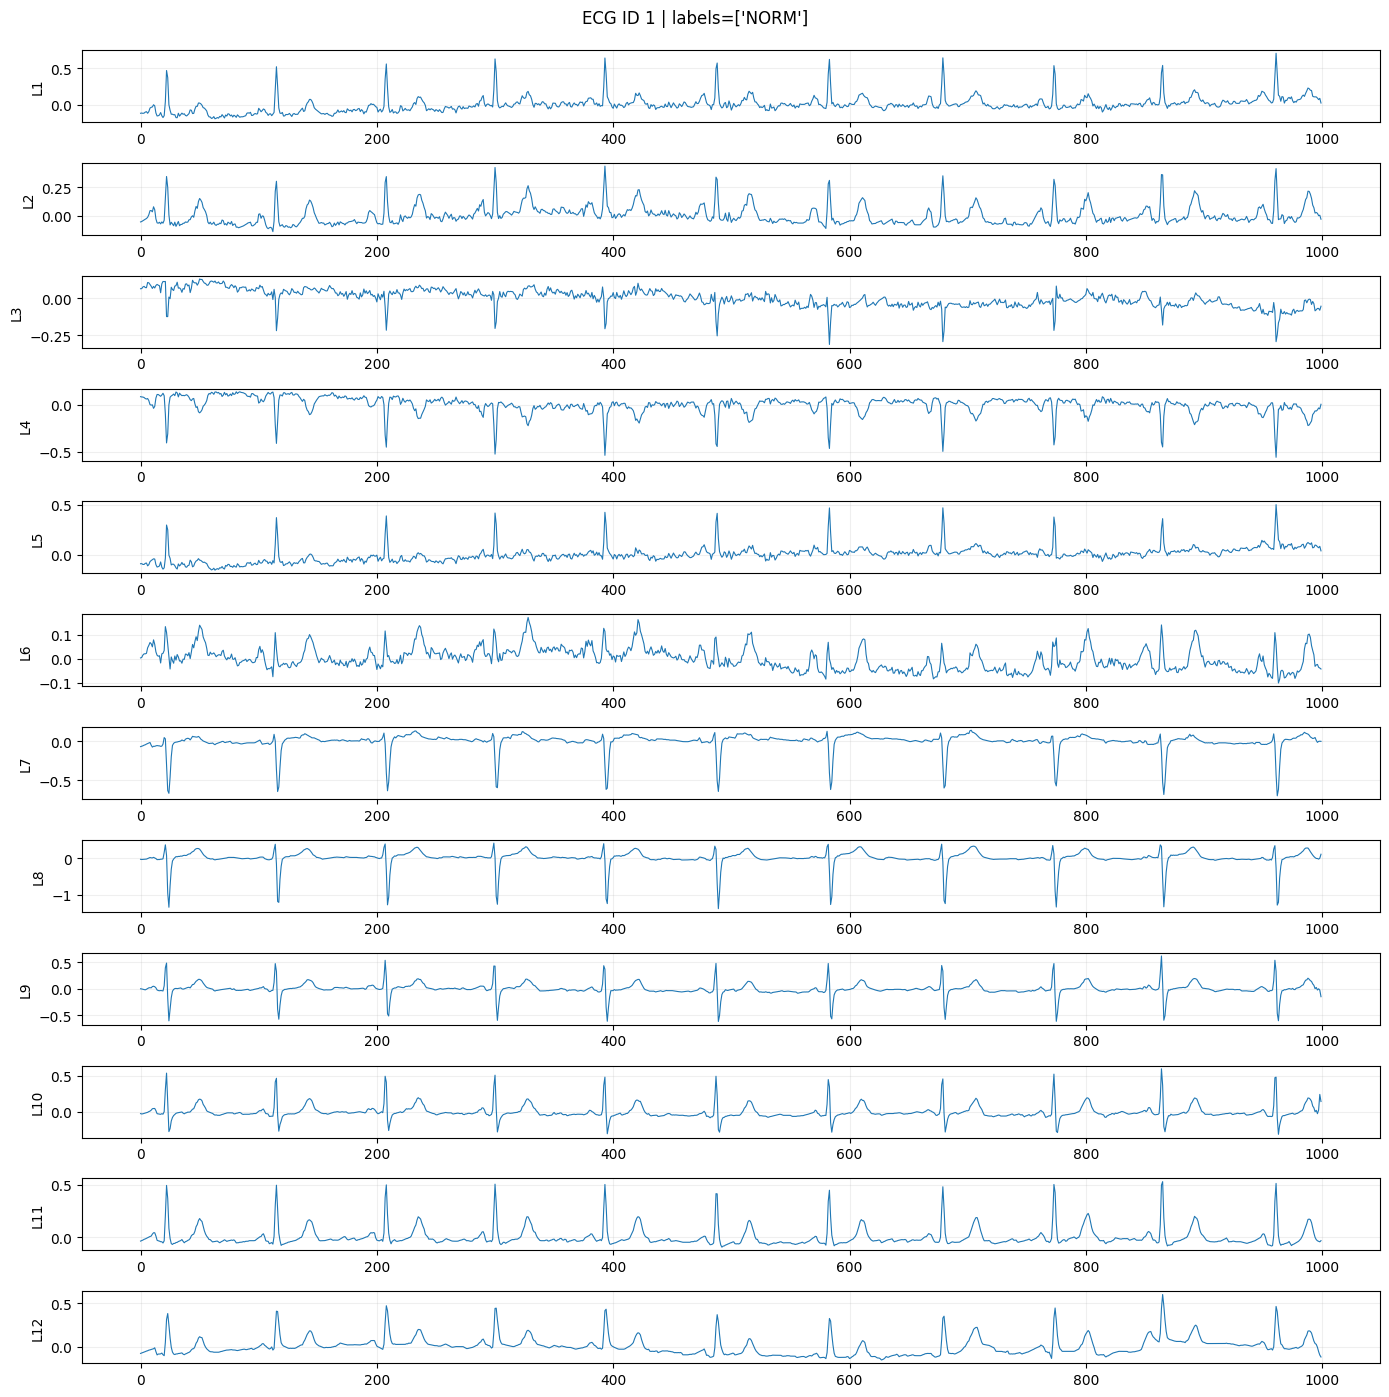

In [ ]:

sample_row = train_df.iloc[0]
sample_path = os.path.join(ROOT_PATH, sample_row[USE_RECORDS])
signal, meta = wfdb.rdsamp(sample_path)

plt.figure(figsize=(14, 14))
for i in range(12):
    plt.subplot(12, 1, i + 1)
    plt.plot(signal[:, i], linewidth=0.8)
    plt.ylabel(f"L{i+1}")
    plt.grid(alpha=0.2)
plt.suptitle(f"ECG ID {sample_row.name} | labels={sample_row['diagnostic_superclasses']}", y=0.995)
plt.tight_layout()
plt.show()


In [ ]:
def augment_signal(x):
    if np.random.rand() < 0.5:
        noise = np.random.normal(0, 0.01, size=x.shape).astype(np.float32)
        x = x + noise

    if np.random.rand() < 0.3:
        scale = np.random.uniform(0.9, 1.1, size=(x.shape[0], 1)).astype(np.float32)
        x = x * scale

    if np.random.rand() < 0.3:
        shift = np.random.randint(-20, 21)
        x = np.roll(x, shift=shift, axis=1)

    return x


In [ ]:
class PTBXLMultilabelDataset(Dataset):
    def __init__(self, df, root_path, filename_col=USE_RECORDS, augment=False):
        self.df = df.reset_index()
        self.root_path = root_path
        self.filename_col = filename_col
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rel_path = row[self.filename_col]
        wfdb_base = os.path.join(self.root_path, rel_path)

        signal, _ = wfdb.rdsamp(wfdb_base)
        signal = signal.T.astype(np.float32)

        mean = signal.mean(axis=1, keepdims=True)
        std = signal.std(axis=1, keepdims=True) + 1e-8
        signal = (signal - mean) / std

        if self.augment:
            signal = augment_signal(signal)

        target = row["target"].astype(np.float32)
        ecg_id = int(row["ecg_id"])

        return (
            torch.tensor(signal, dtype=torch.float32),
            torch.tensor(target, dtype=torch.float32),
            ecg_id,
        )


In [ ]:
train_dataset = PTBXLMultilabelDataset(train_df, ROOT_PATH, augment=True)
val_dataset   = PTBXLMultilabelDataset(val_df, ROOT_PATH, augment=False)
test_dataset  = PTBXLMultilabelDataset(test_df, ROOT_PATH, augment=False)

pin_memory = (DEVICE.type == "cuda")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

print("Ready. pin_memory =", pin_memory)


Ready. pin_memory = False


In [ ]:
class ResidualBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, kernel_size=7, dropout=0.1):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride, padding=pad, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, stride=1, padding=pad, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(dropout)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        out = out + identity
        out = self.relu(out)
        return out


class ResNet1D(nn.Module):
    def __init__(self, in_channels=12, num_classes=5, base=32, dropout=0.1):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, base, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(base),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),
        )

        self.layer1 = nn.Sequential(
            ResidualBlock1D(base, base, stride=1, dropout=dropout),
            ResidualBlock1D(base, base, stride=1, dropout=dropout),
        )
        self.layer2 = nn.Sequential(
            ResidualBlock1D(base, base*2, stride=2, dropout=dropout),
            ResidualBlock1D(base*2, base*2, stride=1, dropout=dropout),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock1D(base*2, base*4, stride=2, dropout=dropout),
            ResidualBlock1D(base*4, base*4, stride=1, dropout=dropout),
        )
        self.layer4 = nn.Sequential(
            ResidualBlock1D(base*4, base*8, stride=2, dropout=dropout),
            ResidualBlock1D(base*8, base*8, stride=1, dropout=dropout),
        )

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(base*8, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).squeeze(-1)
        x = self.head(x)
        return x

model = ResNet1D(in_channels=12, num_classes=len(TARGET_CLASSES), base=32, dropout=0.1).to(DEVICE)
model


ResNet1D(
  (stem): Sequential(
    (0): Conv1d(12, 32, kernel_size=(15,), stride=(2,), padding=(7,), bias=False)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop): Dropout(p=0.1, inplace=False)
      (shortcut): Sequential()
    )
    (1): ResidualBlock1D(
      (conv1): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (bn1): BatchNorm1d(32, eps=1e-05, mome

In [ ]:
train_targets = np.stack(train_df["target"].values)
pos_counts = train_targets.sum(axis=0)
neg_counts = len(train_targets) - pos_counts
pos_weight = (neg_counts / np.maximum(pos_counts, 1)).astype(np.float32)

print("pos_weight:")
for c, w in zip(TARGET_CLASSES, pos_weight):
    print(f"{c}: {w:.3f}")

pos_weight = torch.tensor(pos_weight, dtype=torch.float32, device=DEVICE)


pos_weight:
CD: 3.373
HYP: 7.062
MI: 2.901
NORM: 1.249
STTC: 3.081


In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)


In [ ]:
def probs_to_binary(y_prob, threshold=0.5):
    return (y_prob >= threshold).astype(np.int32)

def evaluate_predictions(y_true, y_prob, threshold=0.5):
    y_pred = probs_to_binary(y_prob, threshold)
    metrics = {}

    metrics["macro_f1"] = f1_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["micro_f1"] = f1_score(y_true, y_pred, average="micro", zero_division=0)
    metrics["samples_f1"] = f1_score(y_true, y_pred, average="samples", zero_division=0)

    try:
        metrics["macro_auroc"] = roc_auc_score(y_true, y_prob, average="macro")
    except ValueError:
        metrics["macro_auroc"] = np.nan

    return metrics, y_pred

def tune_threshold(y_true, y_prob, thresholds=np.arange(0.1, 0.91, 0.05)):
    best_t = 0.5
    best_f1 = -1
    history = []

    for t in thresholds:
        score = f1_score(y_true, probs_to_binary(y_prob, t), average="macro", zero_division=0)
        history.append((float(t), float(score)))
        if score > best_f1:
            best_f1 = score
            best_t = float(t)

    return best_t, best_f1, history


In [ ]:

def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    total_n = 0
    all_probs = []
    all_true = []
    all_ids = []

    for x, y, ecg_ids in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(train_mode):
            logits = model(x)
            loss = criterion(logits, y)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        true = y.detach().cpu().numpy()

        batch_n = x.size(0)
        total_loss += loss.item() * batch_n
        total_n += batch_n

        all_probs.append(probs)
        all_true.append(true)
        all_ids.extend(list(ecg_ids))

    all_probs = np.concatenate(all_probs, axis=0)
    all_true = np.concatenate(all_true, axis=0)

    return {
        "loss": total_loss / max(total_n, 1),
        "y_prob": all_probs,
        "y_true": all_true,
        "ecg_ids": all_ids,
    }


In [ ]:
best_state = None
best_threshold = 0.5
best_val_macro_f1 = -1
best_epoch = -1
patience_counter = 0

history = []

for epoch in range(1, EPOCHS + 1):
    train_out = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_out = run_epoch(model, val_loader, criterion, optimizer=None)

    fixed_threshold = 0.5

    train_metrics, _ = evaluate_predictions(
        train_out["y_true"],
        train_out["y_prob"],
        threshold=fixed_threshold
    )

    val_metrics, _ = evaluate_predictions(
        val_out["y_true"],
        val_out["y_prob"],
        threshold=fixed_threshold
    )

    scheduler.step(val_metrics["macro_f1"])

    row = {
        "epoch": epoch,
        "train_loss": train_out["loss"],
        "val_loss": val_out["loss"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_micro_f1": val_metrics["micro_f1"],
        "val_macro_auroc": val_metrics["macro_auroc"],
        "threshold": fixed_threshold,
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={row['train_loss']:.4f} | "
        f"val_loss={row['val_loss']:.4f} | "
        f"train_macro_f1={row['train_macro_f1']:.4f} | "
        f"val_macro_f1={row['val_macro_f1']:.4f} | "
        f"val_macro_auroc={row['val_macro_auroc']:.4f} | "
        f"thr={row['threshold']:.2f} | "
        f"lr={row['lr']:.6f}"
    )

    if val_metrics["macro_f1"] > best_val_macro_f1:
        best_val_macro_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print("Early stopping triggered.")
        break

print("\nBest epoch:", best_epoch)
print("Best val macro F1:", best_val_macro_f1)

model.load_state_dict(best_state)
val_out = run_epoch(model, val_loader, criterion, optimizer=None)
best_threshold, tuned_f1, tune_hist = tune_threshold(val_out["y_true"], val_out["y_prob"])

print("Post-training tuned threshold:", best_threshold)
print("Post-training tuned val macro F1:", tuned_f1)

Epoch 01 | train_loss=0.6968 | val_loss=0.6477 | train_macro_f1=0.6229 | val_macro_f1=0.6537 | val_macro_auroc=0.8795 | thr=0.50 | lr=0.001000
Epoch 02 | train_loss=0.6088 | val_loss=0.6869 | train_macro_f1=0.6705 | val_macro_f1=0.6210 | val_macro_auroc=0.8834 | thr=0.50 | lr=0.001000
Epoch 03 | train_loss=0.5855 | val_loss=0.6924 | train_macro_f1=0.6813 | val_macro_f1=0.6789 | val_macro_auroc=0.8919 | thr=0.50 | lr=0.001000
Epoch 04 | train_loss=0.5688 | val_loss=0.6530 | train_macro_f1=0.6904 | val_macro_f1=0.6868 | val_macro_auroc=0.8931 | thr=0.50 | lr=0.001000
Epoch 05 | train_loss=0.5491 | val_loss=0.6297 | train_macro_f1=0.6995 | val_macro_f1=0.6554 | val_macro_auroc=0.8926 | thr=0.50 | lr=0.001000
Epoch 06 | train_loss=0.5432 | val_loss=0.6641 | train_macro_f1=0.7018 | val_macro_f1=0.6826 | val_macro_auroc=0.8964 | thr=0.50 | lr=0.001000
Epoch 07 | train_loss=0.5295 | val_loss=0.6250 | train_macro_f1=0.7082 | val_macro_f1=0.6862 | val_macro_auroc=0.8983 | thr=0.50 | lr=0.000500

# New Section

,epoch,train_loss,val_loss,train_macro_f1,val_macro_f1,val_micro_f1,val_macro_auroc,threshold,lr
0,1,0.696771,0.647721,0.622934,0.653701,0.681832,0.879486,0.5,0.00100
1,2,0.608790,0.686869,0.670472,0.620975,0.616941,0.883401,0.5,0.00100
2,3,0.585492,0.692351,0.681293,0.678896,0.722096,0.891896,0.5,0.00100
3,4,0.568761,0.653041,0.690407,0.686840,0.726753,0.893143,0.5,0.00100
4,5,0.549117,0.629725,0.699502,0.655418,0.684562,0.892629,0.5,0.00100
5,6,0.543158,0.664145,0.701791,0.682629,0.721821,0.896430,0.5,0.00100
6,7,0.529469,0.624964,0.708233,0.686216,0.721439,0.898314,0.5,0.00050
7,8,0.493538,0.588774,0.724980,0.689702,0.721924,0.905312,0.5,0.00050
8,9,0.485188,0.639256,0.728987,0.706562,0.747181,0.903181,0.5,0.00050
9,10,0.477795,0.579436,0.733311,0.686606,0.713768,0.906962,0.5,0.00050


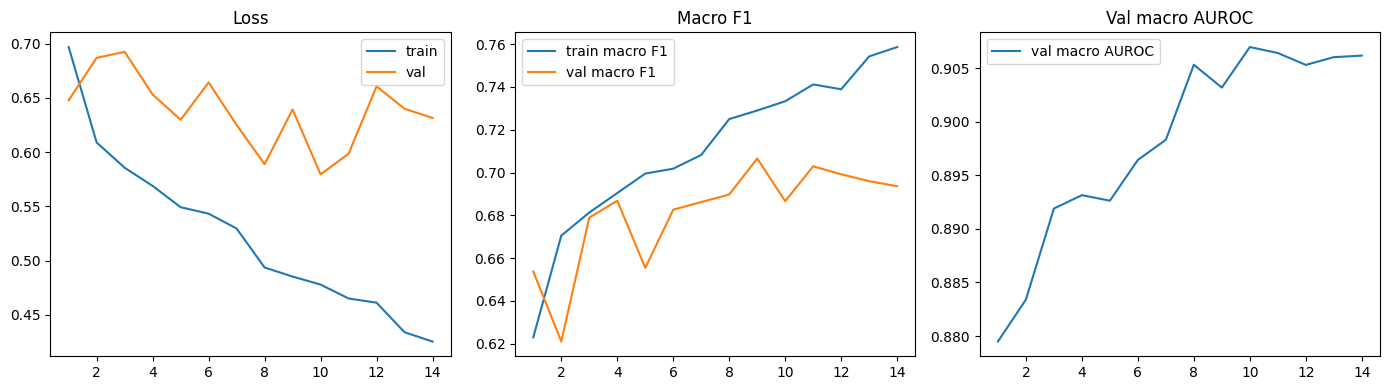

In [ ]:
model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
display(history_df)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="train macro F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="val macro F1")
plt.title("Macro F1")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_df["epoch"], history_df["val_macro_auroc"], label="val macro AUROC")
plt.title("Val macro AUROC")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
test_out = run_epoch(model, test_loader, criterion, optimizer=None)
test_metrics, test_pred = evaluate_predictions(test_out["y_true"], test_out["y_prob"], threshold=best_threshold)

print("Test metrics")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")


Test metrics
macro_f1: 0.7083
micro_f1: 0.7523
samples_f1: 0.7583
macro_auroc: 0.9047


In [ ]:
y_true = test_out["y_true"].astype(int)
y_prob = test_out["y_prob"]
y_pred = test_pred.astype(int)

for i, cls in enumerate(TARGET_CLASSES):
    print("=" * 70)
    print(cls)
    print(classification_report(
        y_true[:, i],
        y_pred[:, i],
        target_names=[f"not_{cls}", cls],
        zero_division=0
    ))


CD
              precision    recall  f1-score   support

      not_CD       0.93      0.90      0.92      1662
          CD       0.70      0.78      0.74       496

    accuracy                           0.87      2158
   macro avg       0.82      0.84      0.83      2158
weighted avg       0.88      0.87      0.88      2158

HYP
              precision    recall  f1-score   support

     not_HYP       0.93      0.90      0.92      1896
         HYP       0.43      0.53      0.47       262

    accuracy                           0.86      2158
   macro avg       0.68      0.72      0.70      2158
weighted avg       0.87      0.86      0.86      2158

MI
              precision    recall  f1-score   support

      not_MI       0.92      0.88      0.90      1608
          MI       0.68      0.78      0.73       550

    accuracy                           0.85      2158
   macro avg       0.80      0.83      0.81      2158
weighted avg       0.86      0.85      0.86      2158

NORM
    

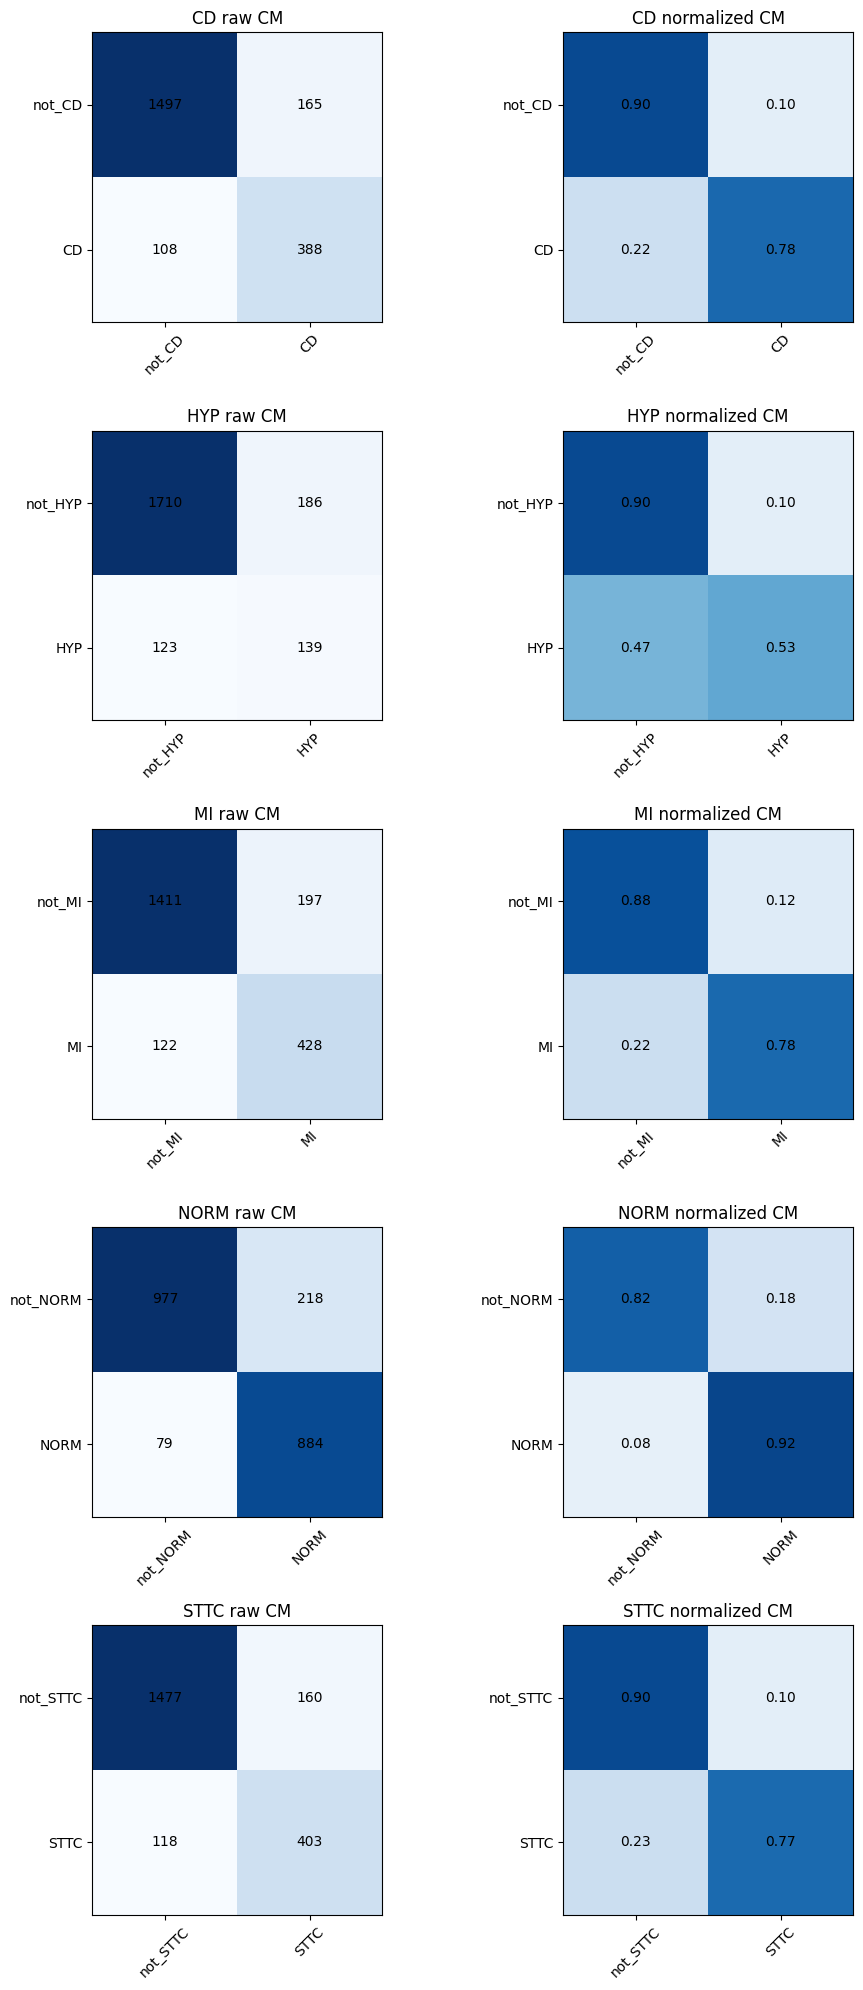

In [ ]:
fig, axes = plt.subplots(len(TARGET_CLASSES), 2, figsize=(10, 4 * len(TARGET_CLASSES)))

for i, cls in enumerate(TARGET_CLASSES):
    cm = confusion_matrix(y_true[:, i], y_pred[:, i], labels=[0,1])

    ax = axes[i, 0]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{cls} raw CM")
    ax.set_xticks([0,1]); ax.set_xticklabels([f"not_{cls}", cls], rotation=45)
    ax.set_yticks([0,1]); ax.set_yticklabels([f"not_{cls}", cls])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha="center", va="center")

    cmn = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    ax = axes[i, 1]
    ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"{cls} normalized CM")
    ax.set_xticks([0,1]); ax.set_xticklabels([f"not_{cls}", cls], rotation=45)
    ax.set_yticks([0,1]); ax.set_yticklabels([f"not_{cls}", cls])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f"{cmn[r, c]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()


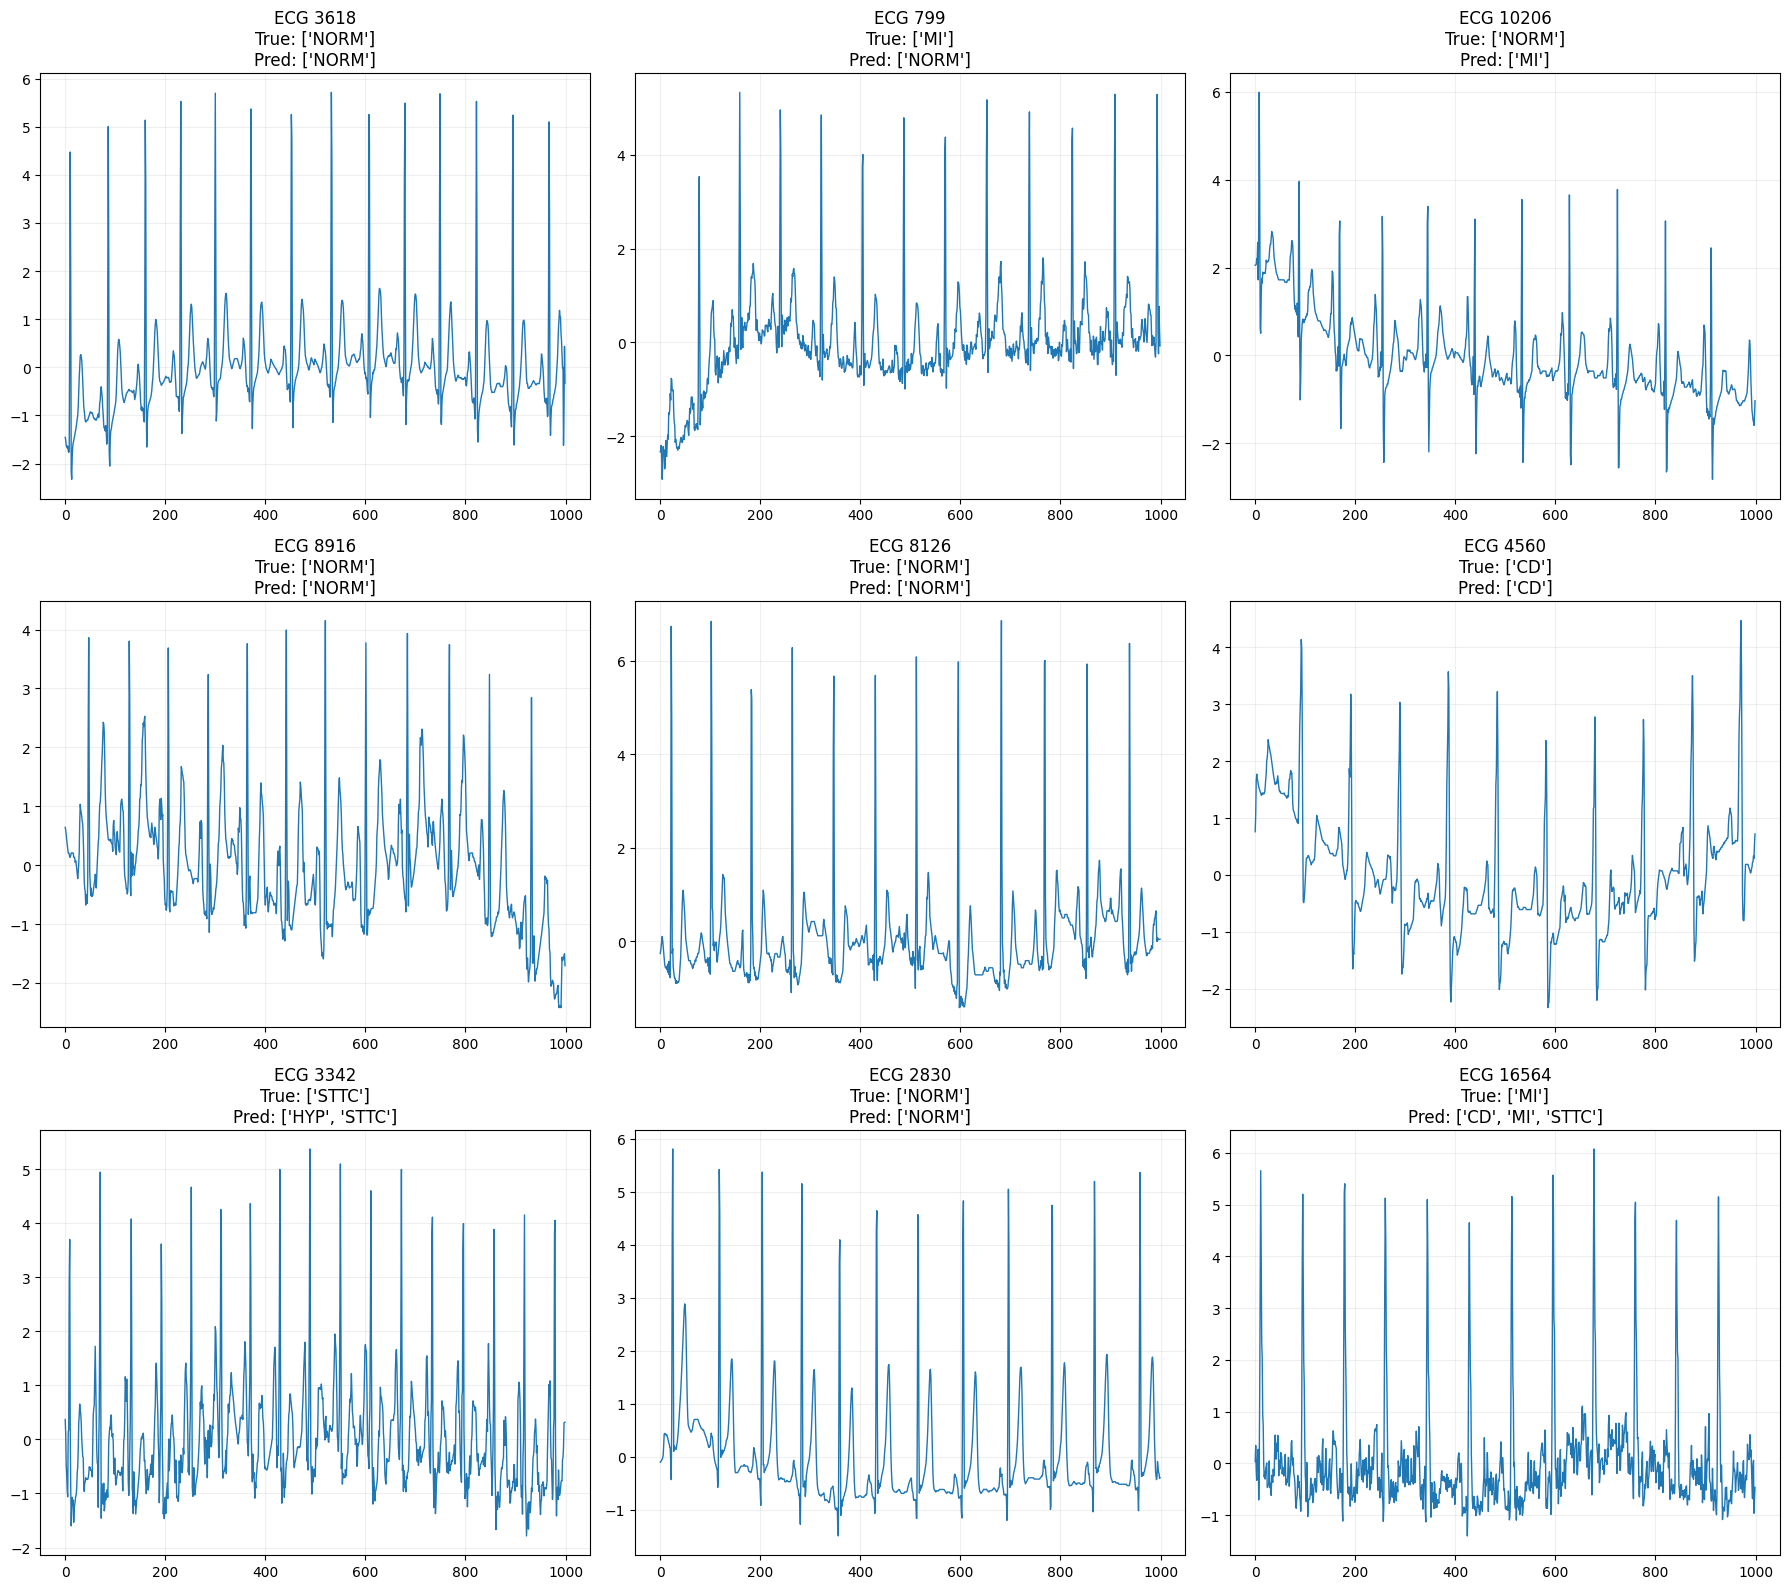

In [ ]:
def predict_single_record(row, model, root_path, threshold):
    wfdb_base = os.path.join(root_path, row[USE_RECORDS])
    signal, _ = wfdb.rdsamp(wfdb_base)
    signal = signal.T.astype(np.float32)

    mean = signal.mean(axis=1, keepdims=True)
    std = signal.std(axis=1, keepdims=True) + 1e-8
    signal_norm = (signal - mean) / std

    x = torch.tensor(signal_norm, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    pred_bin = (probs >= threshold).astype(int)
    pred_labels = [TARGET_CLASSES[i] for i in range(len(TARGET_CLASSES)) if pred_bin[i] == 1]
    true_labels = row["diagnostic_superclasses"]

    return signal_norm, probs, pred_labels, true_labels

sample_indices = random.sample(range(len(test_df)), min(9, len(test_df)))
plt.figure(figsize=(18, 16))

for i, idx in enumerate(sample_indices):
    row = test_df.iloc[idx]
    signal_norm, probs, pred_labels, true_labels = predict_single_record(row, model, ROOT_PATH, best_threshold)

    # show lead II
    plt.subplot(3, 3, i + 1)
    plt.plot(signal_norm[1], linewidth=1)
    plt.title(
        f"ECG {row.name}\n"
        f"True: {true_labels}\n"
        f"Pred: {pred_labels if pred_labels else ['NONE']}"
    )
    plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


In [ ]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "target_classes": TARGET_CLASSES,
    "class_to_idx": class_to_idx,
    "best_threshold": best_threshold,
    "best_val_macro_f1": best_val_macro_f1,
    "best_epoch": best_epoch,
    "history": history,
}
torch.save(checkpoint, "ptbxl_multilabel_resnet1d_checkpoint.pth")
print("Saved:", "ptbxl_multilabel_resnet1d_checkpoint.pth")


Saved: ptbxl_multilabel_resnet1d_checkpoint.pth


In [ ]:
from google.colab import files
from PIL import Image
import cv2

def load_ecg_image_gray(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    return img

def crop_bright_margins(gray, threshold=245):
    mask = gray < threshold
    if not np.any(mask):
        return gray
    ys, xs = np.where(mask)
    y1, y2 = ys.min(), ys.max()
    x1, x2 = xs.min(), xs.max()
    return gray[y1:y2+1, x1:x2+1]

def extract_waveform_from_image(image_path, target_len=1000, debug=False):
    gray = load_ecg_image_gray(image_path)
    gray = crop_bright_margins(gray)

    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    inv = 255 - blur

    _, binary = cv2.threshold(inv, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = np.ones((2, 2), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    h, w = binary.shape
    xs = np.arange(w)
    y_trace = np.full(w, np.nan, dtype=np.float32)

    for x in range(w):
        rows = np.where(binary[:, x] > 0)[0]
        if len(rows) == 0:
            continue

        weights = inv[rows, x].astype(np.float32) + 1.0
        y_trace[x] = np.average(rows.astype(np.float32), weights=weights)

    valid = ~np.isnan(y_trace)
    if valid.sum() < max(20, int(0.1 * w)):
        raise ValueError(
            "Could not extract a usable waveform from this image. "
            "Try a cleaner crop with one visible ECG strip."
        )
    y_trace = np.interp(xs, xs[valid], y_trace[valid]).astype(np.float32)
    y_trace = cv2.GaussianBlur(y_trace.reshape(1, -1), (1, 0), sigmaX=2).reshape(-1)
    signal_1d = -(y_trace - np.mean(y_trace))
    signal_1d = signal_1d.astype(np.float32)

    old_x = np.linspace(0, 1, len(signal_1d))
    new_x = np.linspace(0, 1, target_len)
    signal_1d = np.interp(new_x, old_x, signal_1d).astype(np.float32)

    signal_1d = (signal_1d - signal_1d.mean()) / (signal_1d.std() + 1e-8)

    if debug:
        return {
            "gray": gray,
            "binary": binary,
            "signal_1d": signal_1d,
            "trace_y": y_trace
        }

    return signal_1d

def image_signal_to_model_input(signal_1d, num_leads=12):
    x = np.tile(signal_1d[None, :], (num_leads, 1)).astype(np.float32)
    return torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(DEVICE)

def predict_from_ecg_image(image_path, model, threshold):
    signal_1d = extract_waveform_from_image(image_path, target_len=1000, debug=False)
    x = image_signal_to_model_input(signal_1d, num_leads=12)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    pred_bin = (probs >= threshold).astype(int)
    pred_labels = [TARGET_CLASSES[i] for i in range(len(TARGET_CLASSES)) if pred_bin[i] == 1]

    return signal_1d, probs, pred_labels

print("Image preprocessing helpers ready.")


Image preprocessing helpers ready.


In [ ]:
uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No image uploaded.")

image_path = list(uploaded.keys())[0]
debug_out = extract_waveform_from_image(image_path, target_len=1000, debug=True)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(debug_out["gray"], cmap="gray")
plt.title("Grayscale input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(debug_out["binary"], cmap="gray")
plt.title("Thresholded waveform mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.plot(debug_out["signal_1d"])
plt.title("Extracted 1D waveform")
plt.xlabel("Resampled time")
plt.ylabel("Normalized amplitude")

plt.tight_layout()
plt.show()

print("Uploaded image:", image_path)


KeyboardInterrupt: 

In [ ]:
signal_1d, image_probs, image_pred_labels = predict_from_ecg_image(
    image_path=image_path,
    model=model,
    threshold=best_threshold
)

print("Predicted labels from image:", image_pred_labels if image_pred_labels else ["No label >= threshold"])
print("\nProbabilities:")
for cls, p in zip(TARGET_CLASSES, image_probs):
    print(f"{cls}: {p:.4f}")

plt.figure(figsize=(14, 4))
plt.plot(signal_1d)
plt.title("Waveform extracted from uploaded ECG image")
plt.xlabel("Resampled time")
plt.ylabel("Normalized amplitude")
plt.show()


In [ ]:
torch.save(model, "full_ecg_model.pth")